# PopOut -- Pesquisa Adversarial com MCTS e Árvores de Decisão
**Inteligência Artificial 2025/2026** · Grupo 3

---

## 1. Introdução

Este notebook documenta o projeto desenvolvido no âmbito da unidade curricular de Inteligência Artificial. O trabalho divide-se em duas grandes componentes: a implementação de um agente capaz de jogar **PopOut** utilizando o algoritmo **Monte Carlo Tree Search (MCTS)**, e a construção de **árvores de decisão** treinadas pelo algoritmo **ID3** sobre datasets gerados a partir do próprio jogo.

### 1.1 O que é o PopOut?

O PopOut é uma variante do clássico Connect-4. Para além da jogada habitual de *drop* (largar um disco no topo de uma coluna), cada jogador pode também realizar um *pop* — remover um disco **seu** da **linha inferior** de qualquer coluna. Quando isto acontece, todos os discos acima descem uma posição, alterando potencialmente toda a configuração do tabuleiro.

| Regra | Descrição |
|-------|-----------|
| Drop | Colocar um disco no topo de uma coluna (a gravidade fá-lo cair até à célula vazia mais baixa) |
| Pop | Remover um disco **próprio** da linha inferior; todos os discos acima descem uma posição |
| Vitória | O primeiro jogador a alinhar 4 discos (horizontal / vertical / diagonal) vence |
| Regra especial 1 | Se um *pop* cria 4-em-linha para **ambos** os jogadores, quem fez o *pop* vence |
| Regra especial 2 | Se o tabuleiro está **cheio** e não é possível *drop*, o jogador pode fazer *pop* (se possível) ou declarar **empate** |
| Regra especial 3 | Se o mesmo estado do tabuleiro se repetir **3 vezes**, qualquer jogador pode declarar **empate** |

A introdução do *pop* torna o PopOut consideravelmente mais complexo do que o Connect-4 tradicional: o número de jogadas legais por turno é maior, e a possibilidade de remover peças faz com que posições aparentemente seguras se tornem vulneráveis. Esta complexidade adicional torna-o um problema particularmente interessante para algoritmos de pesquisa adversarial.

### 1.2 Estrutura do Projeto

| Ficheiro | Conteúdo |
|----------|-----------|
| `popout_game.py` | Classe `PopOutGame` — toda a lógica do jogo, aplicação de jogadas, deteção de vitória |
| `mcts.py` | `MCTSNode`, `MCTS` e funções auxiliares para as diferentes variantes |
| `main.py` | Runner interativo por texto (Humano vs Humano / Humano vs IA / IA vs IA) |
| `Relatório.ipynb` | **Este notebook** — documentação, experiências, geração de datasets, árvores de decisão |

---
## 2. Implementação do Jogo PopOut

A classe `PopOutGame` encapsula toda a lógica do jogo. Optámos por um design **imutável**: cada jogada devolve um **novo** estado, sem alterar o original. Esta decisão facilita a integração com o MCTS, onde se criam e exploram múltiplas ramificações sem risco de corromper o estado de referência.

### 2.1 Decisões de Design

- **Representação do tabuleiro:** Matriz `6×7` de inteiros (`0` = vazio, `1` = Jogador 1, `2` = Jogador 2). A linha 0 corresponde ao topo.
- **Histórico de estados:** Um dicionário que mapeia cada configuração `(tabuleiro, jogador_atual)` ao número de ocorrências. Permite verificar a regra de empate por repetição sem percorrer todo o histórico de jogadas.
- **Cópia eficiente:** O método `_copy()` usa `object.__new__` para evitar a re-execução do `__init__`, copiando apenas os atributos necessários. Isto é relevante porque o MCTS cria milhares de cópias por decisão.

### 2.2 Funções Principais

- **`get_all_moves()`** — Devolve todas as jogadas legais, combinando *drops* (colunas com espaço) e *pops* (colunas onde o jogador atual tem disco na base).
- **`apply_move(move_type, col)`** — Cria uma cópia do estado, aplica a jogada, e resolve o resultado (vitória, empate, ou troca de turno).
- **`_check_four_in_row(player)`** — Verifica as quatro direções possíveis (horizontal, vertical, e duas diagonais) para detetar alinhamentos de 4 peças.
- **`_resolve_after_pop()`** — Implementa a regra especial: se ambos os jogadores ficam com 4-em-linha após um *pop*, quem fez o *pop* vence.

In [1]:
# Toda a lógica do jogo está em popout_game.py — importamos do módulo para
# garantir uma única fonte de verdade (sem drift entre notebook e código).
import math, random, time, csv, os
from copy import deepcopy

from popout_game import PopOutGame, PLAYER1, PLAYER2, EMPTY

# Pequena verificação: criar um tabuleiro vazio e listar as jogadas iniciais.
g0 = PopOutGame()
print(f'PopOutGame importado de popout_game.py — tabuleiro {g0.rows}x{g0.cols}.')
print(f'Jogadas iniciais legais: {len(g0.get_all_moves())}')
print(f'Símbolos: PLAYER1={PopOutGame.player_symbol(PLAYER1)},'
      f' PLAYER2={PopOutGame.player_symbol(PLAYER2)}')


PopOutGame importado de popout_game.py — tabuleiro 6x7.
Jogadas iniciais legais: 7
Símbolos: PLAYER1=X, PLAYER2=O


### 2.3 Demonstração — algumas jogadas manuais

Para validar a implementação, executamos uma sequência de jogadas e verificamos que o tabuleiro, a troca de turnos e a deteção de jogadas legais funcionam corretamente.

In [2]:
g = PopOutGame()
# Largar alguns discos
for col in [3, 3, 3, 4, 2, 5]:
    g = g.apply_move('drop', col)
g.display()
print('Jogadas disponíveis:', g.get_all_moves())


-------
-------
-------
---X---
---O---
--XXOO-
1234567

It is X's turn.

Jogadas disponíveis: [('drop', 0), ('drop', 1), ('drop', 2), ('drop', 3), ('drop', 4), ('drop', 5), ('drop', 6), ('pop', 2), ('pop', 3)]


In [3]:
# Demonstração da jogada pop: preencher a coluna 3 e depois fazer pop
g2 = PopOutGame()
for col in [3,3,3,3,3,3]:
    g2 = g2.apply_move('drop', col)
    if g2 is None:
        print('Coluna cheia'); break
if g2:
    g2.display()
    print('Jogadas pop disponíveis para X:', g2.get_pop_moves())
    g3 = g2.apply_move('pop', 3)
    if g3:
        print('Após pop na coluna 3:')
        g3.display()


---O---
---X---
---O---
---X---
---O---
---X---
1234567

It is X's turn.

Jogadas pop disponíveis para X: [3]
Após pop na coluna 3:

-------
---O---
---X---
---O---
---X---
---O---
1234567

It is O's turn.



---
## 3. Monte Carlo Tree Search (MCTS)

O MCTS é um algoritmo de pesquisa adversarial que utiliza **simulação aleatória (Monte Carlo)** para estimar o valor de cada jogada sem necessitar de uma função de avaliação manual. Este é o principal algoritmo utilizado neste projeto para dotar a IA de capacidade de jogo.

### 3.1 As Quatro Fases

O algoritmo opera em ciclos de quatro fases:

1. **Seleção** — A partir da raiz, percorre-se a árvore escolhendo sucessivamente o filho que maximiza o valor **UCT**, até se atingir um nó que não esteja totalmente expandido (ou um nó terminal).

2. **Expansão** — Adiciona-se um novo nó filho correspondente a uma jogada ainda não explorada. É aqui que a árvore cresce.

3. **Simulação (Rollout)** — A partir do novo nó, joga-se aleatoriamente (ou com heurística) até ao final do jogo. O resultado deste "jogo rápido" serve de estimativa da qualidade da posição.

4. **Retropropagação** — O resultado da simulação é propagado de volta até à raiz, atualizando contagens de visitas e somas de vitórias ao longo de todo o caminho.

### 3.2 Fórmula UCT

A seleção do filho a explorar é governada pelo **Upper Confidence Bound for Trees (UCT)**:

$$\text{UCT}(v') = \underbrace{\frac{Q(v')}{N(v')}}_{\text{exploração dos ganhos}} + C \cdot \underbrace{\sqrt{\frac{\ln N(v)}{N(v')}}}_{\text{exploração do desconhecido}}$$

onde:
- $Q(v')$ = vitórias acumuladas no filho $v'$ (da perspetiva do **jogador do filho**)
- $N(v')$ = número de visitas ao filho $v'$
- $N(v)$ = número de visitas ao pai $v$
- $C$ = constante de exploração (tipicamente $\sqrt{2} \approx 1.414$)

Na nossa implementação, como $Q/N$ está armazenado da perspetiva do jogador do **filho** (que é o adversário do jogador do nó atual), o pai seleciona usando $(1 - Q/N) + C\sqrt{\ldots}$, invertendo a perspetiva para a do jogador corrente.

O parâmetro $C$ controla o equilíbrio entre **exploitation** (explorar jogadas já conhecidas como boas) e **exploration** (visitar jogadas menos testadas). Um $C$ alto diversifica a pesquisa; um $C$ baixo concentra-a nas melhores opções conhecidas.

### 3.3 Variantes Implementadas

Para além da implementação base, explorámos seis configurações distintas do MCTS para compreender o impacto de diferentes estratégias:

| Variante | Diferença principal |
|----------|---------------------|
| Standard UCT | $C = \sqrt{2}$ — configuração clássica da literatura |
| Alta exploração | $C = 2.5$ — árvore mais larga, pesquisa menos profunda |
| Baixa exploração (greedy) | $C = 0.5$ — foco quase exclusivo em jogadas promissoras |
| Progressive widening | Limite de filhos por nó (`max_children`) — reduz o branching factor |
| Heuristic rollout | Look-ahead de 1 passo durante simulação: prefere vitórias e bloqueios imediatos |
| UCT-Tuned | Substitui o termo de exploração por um *bound* baseado na variância empírica |

### 3.4 Implementação

A implementação está dividida em duas classes: `MCTSNode` (cada nó da árvore de pesquisa) e `MCTS` (o algoritmo propriamente dito).

**`MCTSNode`** armazena:
- O estado do jogo nesse ponto
- Referência ao pai e à jogada que levou a este nó
- Lista de filhos já expandidos
- Estatísticas: vitórias acumuladas (`wins`) e visitas (`visits`)
- Jogadas ainda não experimentadas (`untried_moves`)

Utilizamos `__slots__` para reduzir o consumo de memória — relevante quando a árvore cresce para dezenas de milhares de nós.

**`MCTS`** recebe como parâmetros o número de iterações, a constante $C$, o limite de filhos (progressive widening), a estratégia de rollout e a flag para UCT-Tuned. O método principal `get_best_move` executa o ciclo completo e devolve a jogada com mais visitas na raiz (política *robust child*).

In [4]:
# Implementação completa em mcts.py — importamos para evitar duplicação.
# Inclui: Standard, High/Low Exploration, Heuristic Rollout, Progressive
# Widening, UCT-Tuned. Cada variante tem uma factory dedicada em mcts.py.
from mcts import (MCTSNode, MCTS,
                  make_standard_mcts, make_high_exploration_mcts,
                  make_low_exploration_mcts, make_heuristic_mcts,
                  make_progressive_widening_mcts, make_tuned_uct_mcts)

# Pequena verificação: instanciar o MCTS standard e mostrar a sua configuração.
ai_demo = make_standard_mcts(iterations=200)
print(f'MCTS pronto: {ai_demo.name}')
print(f'  iterations           = {ai_demo.iterations}')
print(f'  exploration_constant = {ai_demo.exploration_constant:.4f} (=√2)')
print(f'  rollout_strategy     = {ai_demo.rollout_strategy}')
print(f'  use_tuned_uct        = {ai_demo.use_tuned_uct}')


MCTS pronto: MCTS-Standard
  iterations           = 200
  exploration_constant = 1.4142 (=√2)
  rollout_strategy     = random
  use_tuned_uct        = False


### 3.5 Teste de sanidade — a IA escolhe a jogada vencedora

Antes de avançar para experiências mais complexas, é fundamental verificar que o MCTS funciona corretamente num cenário simples: quando existe uma vitória imediata disponível, o algoritmo deve encontrá-la consistentemente, mesmo com poucas iterações.

In [5]:
# Configurar um estado em que X (PLAYER1) pode vencer imediatamente
# X tem 3 em linha na base (cols 0,1,2); vitória com drop_3
g = PopOutGame()
for m in [('drop',0),('drop',5), ('drop',1),('drop',5), ('drop',2),('drop',6)]:
    g = g.apply_move(*m)
g.display()

legal_win = g.apply_move('drop', 3)
print(f'Jogada vencedora drop_3: game_over={legal_win.game_over}, winner=P{legal_win.winner}')
print()

random.seed(0)
ai = MCTS(iterations=500, exploration_constant=math.sqrt(2),
          name='Teste-Sanidade')
move = ai.get_best_move(g)
print(f'IA escolheu: {move[0].upper()} coluna {move[1]+1}  {'✓ CORRETO' if move == ('drop',3) else '(jogada razoável)'}' )
g2 = g.apply_move(*move)
g2.display()


-------
-------
-------
-------
-----O-
XXX--OO
1234567

It is X's turn.

Jogada vencedora drop_3: game_over=True, winner=P1

IA escolheu: DROP coluna 4  ✓ CORRETO

-------
-------
-------
-------
-----O-
XXXX-OO
1234567

X wins!



---
## 4. Modos de Jogo

O enunciado exige três modos de jogo: **humano vs humano**, **humano vs computador**, e **computador vs computador**. A implementação interativa encontra-se em `main.py`, onde o jogador pode escolher o modo e o algoritmo. Para jogos automatizados (IA vs IA), usamos o helper `auto_play` que executa um jogo completo entre dois agentes MCTS.

O modo IA vs IA é particularmente útil para:
- Comparar variantes do MCTS de forma controlada
- Gerar datasets para as árvores de decisão
- Recolher estatísticas sobre desempenho relativo

In [6]:
def auto_play(ai1, ai2, verbose=False):
    """
    Executa um jogo completo entre dois agentes MCTS.
    Devolve (vencedor, n_jogadas, tempo_por_jogada).
    vencedor = PLAYER1 | PLAYER2 | None (empate).
    """
    game = PopOutGame()
    n = 0
    times = []
    while not game.game_over:
        if game.is_repetition_draw_available():
            if verbose: print('[Empate por repetição]')
            return None, n, times
        ai = ai1 if game.current_player == PLAYER1 else ai2
        t0 = time.time()
        move = ai.get_best_move(game)
        times.append(time.time() - t0)
        if move is None: break
        ng = game.apply_move(*move)
        if ng is None: break
        game = ng
        n += 1
    if verbose: game.display()
    return game.winner, n, times

# Demonstração rápida: um jogo IA vs IA
random.seed(0)
ai_x = MCTS(iterations=300, exploration_constant=math.sqrt(2), name='X-Standard')
ai_o = MCTS(iterations=300, exploration_constant=math.sqrt(2), name='O-Standard')
winner, n_moves, _ = auto_play(ai_x, ai_o, verbose=False)
print(f'Demonstração: {n_moves} jogadas, vencedor = '
      f'{PopOutGame.player_symbol(winner) if winner else "Empate"}')


Demonstração: 8 jogadas, vencedor = O


---
## 5. Experiências — Comparação de Variantes MCTS

Para compreender o impacto de cada variante, organizámos um **torneio round-robin**: cada par de variantes joga `N_GAMES` partidas, alternando quem começa como X. Esta alternância é importante porque no PopOut (tal como no Connect-4), o primeiro jogador tem uma ligeira vantagem estrutural.

As seis configurações testadas representam diferentes filosofias de pesquisa:
- **Standard** — a linha de base, com $C = \sqrt{2}$ conforme a literatura original
- **Alta exploração** — testa se vale a pena sacrificar profundidade por diversidade
- **Baixa exploração** — o oposto: foco máximo nas melhores jogadas conhecidas
- **Progressive widening** — limitar o número de filhos por nó pode ajudar quando o branching factor é elevado
- **Heuristic rollout** — substitui jogadas completamente aleatórias por um look-ahead de 1 passo
- **UCT-Tuned** — adapta a exploração com base na variância observada dos resultados

In [7]:
# Definir as variantes — usamos a API formal de mcts.py
ITERS = 250   # valor moderado para o notebook; aumentar para mais robustez

variants = [
    MCTS(iterations=ITERS, exploration_constant=math.sqrt(2),
         name='Standard (C=√2)'),
    MCTS(iterations=ITERS, exploration_constant=2.5,
         name='Alta-Expl (C=2.5)'),
    MCTS(iterations=ITERS, exploration_constant=0.5,
         name='Baixa-Expl (C=0.5)'),
    MCTS(iterations=ITERS, exploration_constant=math.sqrt(2),
         max_children=4, name='Prog-Widening(k=4)'),
    MCTS(iterations=ITERS, exploration_constant=math.sqrt(2),
         rollout_strategy='heuristic', name='Heuristic-Rollout'),
    MCTS(iterations=ITERS, exploration_constant=math.sqrt(2),
         use_tuned_uct=True, name='UCT-Tuned'),
]
print('Variantes definidas:')
for v in variants: print(f'  {v.name}')


Variantes definidas:
  Standard (C=√2)
  Alta-Expl (C=2.5)
  Baixa-Expl (C=0.5)
  Prog-Widening(k=4)
  Heuristic-Rollout
  UCT-Tuned


In [8]:
def tournament(variants, n_games=10, seed=0):
    """
    Torneio round-robin entre as variantes MCTS.
    Cada par (i, j) joga `n_games` partidas (metade com i a começar como X,
    metade com j a começar como X). Devolve a matriz W[i][j] de vitórias de
    i contra j (com empates contando como 0.5 para ambos os lados).
    """
    random.seed(seed)
    n = len(variants)
    W = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i == j: continue
            for game_idx in range(n_games):
                if game_idx % 2 == 0:
                    ai_x, ai_o = variants[i], variants[j]
                    label_x = i
                else:
                    ai_x, ai_o = variants[j], variants[i]
                    label_x = j
                winner, _, _ = auto_play(ai_x, ai_o)
                if winner is None:               # empate
                    W[i][j] += 0.5
                elif winner == PLAYER1 and label_x == i:
                    W[i][j] += 1
                elif winner == PLAYER2 and label_x == j:
                    W[i][j] += 1
    return W

# Para o notebook usamos um número reduzido de partidas (rapidez).
# Para a versão final, sugerimos N_GAMES=10 (cada par joga 10 partidas).
N_GAMES = 4
print(f'A correr torneio round-robin: {len(variants)} variantes × '
      f'{N_GAMES} partidas/par = {len(variants)*(len(variants)-1)*N_GAMES} jogos…')
t0 = time.time()
W = tournament(variants, n_games=N_GAMES, seed=42)
print(f'Concluído em {time.time()-t0:.1f}s')


A correr torneio round-robin: 6 variantes × 4 partidas/par = 120 jogos…


Concluído em 251.6s


In [9]:
# Tabela de resultados (matriz N×N de vitórias)
n = len(variants)
names = [v.name for v in variants]
totals = [sum(W[i]) for i in range(n)]
games_per_variant = (n - 1) * N_GAMES   # jogos totais de cada variante

col_w = max(len(nm) for nm in names) + 2
header = f"{'Variante':<{col_w}}" + ''.join(f'{i:>5}' for i in range(n)) + '   TOTAL  WIN%'
print(header)
print('-' * len(header))
for i, nm in enumerate(names):
    row = f'{nm:<{col_w}}'
    for j in range(n):
        row += f'{W[i][j]:>5.1f}' if j != i else '    -'
    win_pct = 100 * totals[i] / games_per_variant
    row += f'  {totals[i]:>6.1f}  {win_pct:>4.0f}%'
    print(row)

# Ranking (mais vitórias primeiro)
ranking = sorted(range(n), key=lambda i: -totals[i])
print('\nRanking:')
for rank, i in enumerate(ranking, start=1):
    win_pct = 100 * totals[i] / games_per_variant
    print(f'  {rank}. {names[i]:<{col_w}} {totals[i]:>5.1f} vitórias ({win_pct:.0f}%)')


Variante                0    1    2    3    4    5   TOTAL  WIN%
----------------------------------------------------------------
Standard (C=√2)         -  1.0  1.0  4.0  1.0  3.0    10.0    50%
Alta-Expl (C=2.5)     2.0    -  1.0  3.0  1.0  2.0     9.0    45%
Baixa-Expl (C=0.5)    3.0  2.0    -  3.0  0.0  2.0    10.0    50%
Prog-Widening(k=4)    1.0  0.0  0.0    -  0.0  0.0     1.0     5%
Heuristic-Rollout     4.0  4.0  2.0  4.0    -  2.0    16.0    80%
UCT-Tuned             2.0  2.0  1.0  4.0  3.0    -    12.0    60%

Ranking:
  1. Heuristic-Rollout     16.0 vitórias (80%)
  2. UCT-Tuned             12.0 vitórias (60%)
  3. Standard (C=√2)       10.0 vitórias (50%)
  4. Baixa-Expl (C=0.5)    10.0 vitórias (50%)
  5. Alta-Expl (C=2.5)      9.0 vitórias (45%)
  6. Prog-Widening(k=4)     1.0 vitórias (5%)


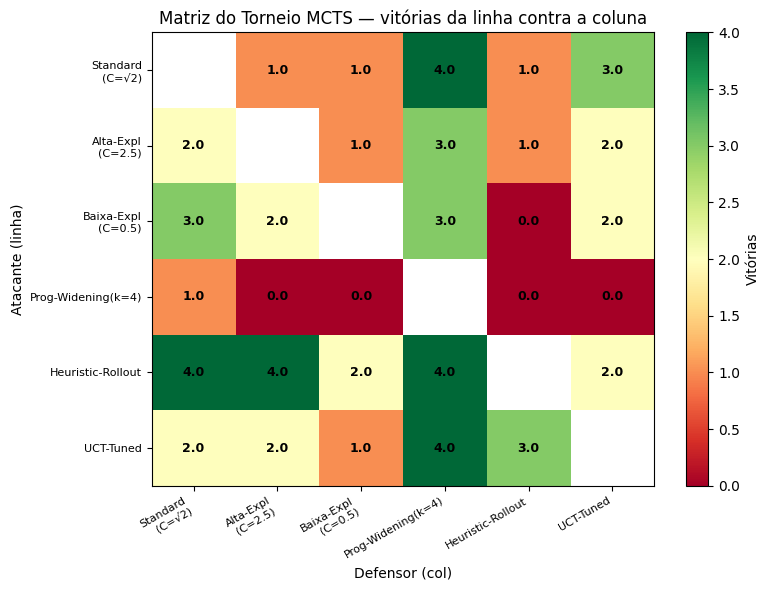

In [10]:
# Heatmap da matriz do torneio: linhas = "ataque", colunas = "defesa".
# Cor = vitórias da variante da linha contra a variante da coluna.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
M = np.array(W, dtype=float)
np.fill_diagonal(M, np.nan)
im = ax.imshow(M, cmap='RdYlGn', vmin=0, vmax=N_GAMES, aspect='auto')

short_names = [n.replace(' ', '\n') for n in names]
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(short_names, fontsize=8, rotation=30, ha='right')
ax.set_yticklabels(short_names, fontsize=8)
ax.set_xlabel('Defensor (col)'); ax.set_ylabel('Atacante (linha)')
ax.set_title('Matriz do Torneio MCTS — vitórias da linha contra a coluna')

for i in range(n):
    for j in range(n):
        if i == j: continue
        ax.text(j, i, f'{W[i][j]:.1f}', ha='center', va='center',
                color='black', fontsize=9, weight='bold')

plt.colorbar(im, ax=ax, label='Vitórias')
plt.tight_layout()
plt.show()


### 5.1 Efeito do orçamento de iterações

Um dos parâmetros mais óbvios do MCTS é o número de iterações — quantas vezes o ciclo seleção-expansão-simulação-retropropagação é executado. Naturalmente, mais iterações permitem explorar mais a árvore, mas a relação não é linear: há rendimentos decrescentes, especialmente em posições com poucos movimentos legais (final do jogo).

Testamos o MCTS Standard com diferentes orçamentos contra uma baseline fraca (50 iterações) para quantificar esta relação.

In [11]:
# Comparar MCTS Standard com diferentes orçamentos vs baseline fraca (50 iter)
random.seed(7)
baseline = MCTS(iterations=50, exploration_constant=math.sqrt(2), name='Fraco(50)')
budgets  = [100, 250, 500, 1000, 2000]
REPS     = 4

print(f'Curva orçamento → win-rate vs Fraco(50) ({REPS} jogos cada):')
print(f'{"Iter":>6}  {"Win%":>6}  {"Tempo médio/jogada (s)":>22}')
print('-' * 38)

curve_results = []
for n_iter in budgets:
    strong = MCTS(iterations=n_iter, exploration_constant=math.sqrt(2),
                  name=f'Forte({n_iter})')
    wins, all_times = 0, []
    for k in range(REPS):
        ai1, ai2 = (strong, baseline) if k % 2 == 0 else (baseline, strong)
        p_strong = PLAYER1 if k % 2 == 0 else PLAYER2
        w, _, times = auto_play(ai1, ai2)
        if w == p_strong: wins += 1
        # Apenas as jogadas do "strong" (alternadas pelo lado)
        strong_idx = 0 if k % 2 == 0 else 1
        all_times += times[strong_idx::2]
    avg_t = sum(all_times) / len(all_times) if all_times else 0.0
    curve_results.append((n_iter, wins / REPS, avg_t))
    print(f'{n_iter:>6}  {100*wins/REPS:>5.0f}%  {avg_t:>22.3f}')


Curva orçamento → win-rate vs Fraco(50) (4 jogos cada):
  Iter    Win%  Tempo médio/jogada (s)
--------------------------------------


   100     25%                   0.032


   250    100%                   0.077


   500    100%                   0.135


  1000    100%                   0.279


  2000    100%                   0.513


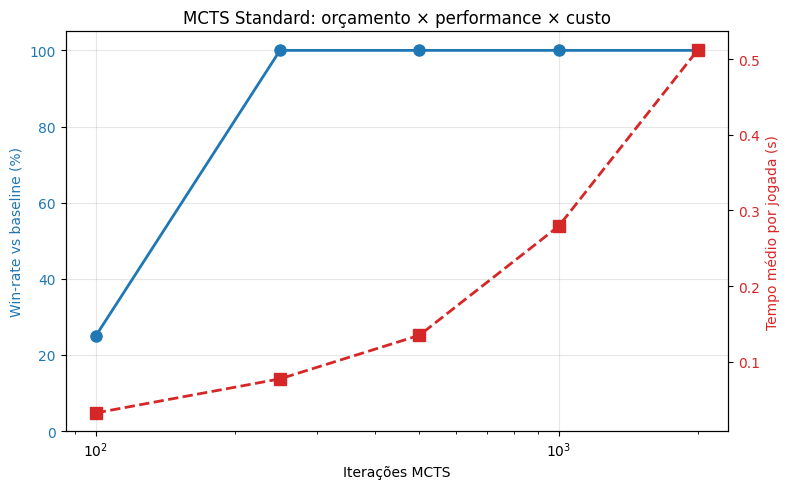

In [12]:
# Gráfico: iterações × win-rate × tempo médio por jogada.
import matplotlib.pyplot as plt

xs   = [r[0] for r in curve_results]
wins = [100 * r[1] for r in curve_results]
times = [r[2] for r in curve_results]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(xs, wins, 'o-', color='tab:blue', linewidth=2, markersize=8,
         label='Win-rate (%)')
ax1.set_xlabel('Iterações MCTS')
ax1.set_ylabel('Win-rate vs baseline (%)', color='tab:blue')
ax1.set_xscale('log')
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(xs, times, 's--', color='tab:red', linewidth=2, markersize=8,
         label='Tempo (s/jogada)')
ax2.set_ylabel('Tempo médio por jogada (s)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('MCTS Standard: orçamento × performance × custo')
fig.tight_layout()
plt.show()


Ablation C — 250 iter, 4 jogos vs Fraco(50):
     C    Win%    Tempo (s/jogada)
----------------------------------


 0.500    100%               0.071


 1.000     75%               0.068


 1.414    100%               0.069


 2.000    100%               0.071


 2.500     75%               0.076


 3.000    100%               0.078


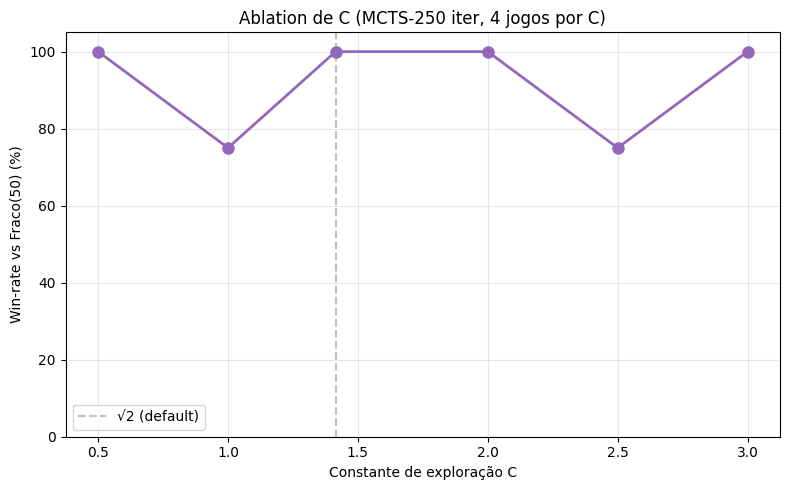

In [13]:
# Ablation do C (constante de exploração): C ∈ {0.5, 1.0, √2, 2.0, 2.5, 3.0}
# vs baseline fraca (50 iter, C=√2). Cada valor de C joga REPS partidas.
random.seed(9)
C_VALUES = [0.5, 1.0, math.sqrt(2), 2.0, 2.5, 3.0]
ITERS_AB = 250
REPS_AB  = 4
baseline_ab = MCTS(iterations=50, exploration_constant=math.sqrt(2),
                   name='Fraco(50)')

print(f'Ablation C — {ITERS_AB} iter, {REPS_AB} jogos vs Fraco(50):')
print(f'{"C":>6}  {"Win%":>6}  {"Tempo (s/jogada)":>18}')
print('-' * 34)
c_results = []
for C in C_VALUES:
    strong = MCTS(iterations=ITERS_AB, exploration_constant=C,
                  name=f'C={C:.3f}')
    wins, all_times = 0, []
    for k in range(REPS_AB):
        ai1, ai2 = (strong, baseline_ab) if k % 2 == 0 else (baseline_ab, strong)
        p_strong = PLAYER1 if k % 2 == 0 else PLAYER2
        w, _, times = auto_play(ai1, ai2)
        if w == p_strong: wins += 1
        strong_idx = 0 if k % 2 == 0 else 1
        all_times += times[strong_idx::2]
    avg_t = sum(all_times) / len(all_times) if all_times else 0.0
    c_results.append((C, wins / REPS_AB, avg_t))
    print(f'{C:>6.3f}  {100*wins/REPS_AB:>5.0f}%  {avg_t:>18.3f}')

# Plot
import matplotlib.pyplot as plt
xs   = [r[0] for r in c_results]
wins = [100 * r[1] for r in c_results]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, wins, 'o-', color='tab:purple', linewidth=2, markersize=8)
ax.axvline(math.sqrt(2), color='gray', linestyle='--', alpha=0.5, label='√2 (default)')
ax.set_xlabel('Constante de exploração C')
ax.set_ylabel('Win-rate vs Fraco(50) (%)')
ax.set_title(f'Ablation de C (MCTS-{ITERS_AB} iter, {REPS_AB} jogos por C)')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### 5.2 Visualização das estatísticas UCT

Para ganhar intuição sobre como o MCTS distribui o seu orçamento de simulações, podemos examinar as estatísticas de cada jogada possível a partir da posição inicial. Numa posição simétrica como o tabuleiro vazio, esperamos que a coluna central receba mais visitas (por ser estrategicamente mais forte no Connect-4 e variantes).

In [14]:
# Distribuição de visitas/win-rate para cada jogada possível a partir do estado inicial
random.seed(0)
start = PopOutGame()
ai = MCTS(iterations=500, exploration_constant=math.sqrt(2), name='Stats')
stats = ai.get_move_stats(start)

print('Estatísticas por jogada a partir da posição inicial (X a jogar):')
print(f'{"Jogada":<12} {"Visitas":>8} {"Win-rate":>10}')
print('-' * 32)
for move, s in sorted(stats.items(), key=lambda x: -x[1]['visits']):
    mtype, col = move
    print(f'{mtype.upper()+" col "+str(col+1):<12} {s["visits"]:>8} {s["win_rate"]:>10.3f}')


Estatísticas por jogada a partir da posição inicial (X a jogar):
Jogada        Visitas   Win-rate
--------------------------------
DROP col 5        101      0.416
DROP col 7         79      0.456
DROP col 1         76      0.474
DROP col 4         70      0.486
DROP col 6         63      0.508
DROP col 3         63      0.508
DROP col 2         48      0.583


---
## 6. Geração de Dataset para Árvores de Decisão

A segunda parte do projeto consiste em treinar uma árvore de decisão que consiga prever a jogada recomendada pelo MCTS dado um estado do tabuleiro. Para isso, precisamos primeiro de gerar um dataset de pares `(estado, jogada_ótima)`.

### 6.1 Codificação do Estado

Cada posição do tabuleiro 6x7 é codificada como um vetor de 42 valores inteiros, sempre **da perspetiva do jogador atual**:
- `0` = célula vazia
- `1` = disco do jogador atual
- `2` = disco do adversário

Esta normalização é fundamental: ao treinar a árvore de decisão, o modelo aprende padrões que se aplicam independentemente de qual jogador está a jogar. Sem esta codificação relativa, a árvore teria de aprender regras duplicadas — umas para o Jogador 1, outras para o Jogador 2.

### 6.2 Rótulo da Jogada

O rótulo (label) combina o tipo de jogada com a coluna: `drop_3`, `pop_1`, etc. Este formato permite à árvore de decisão capturar tanto a escolha da coluna como a distinção entre *drop* e *pop* numa única classificação.

In [15]:
# A geração formal está em generate_dataset.py. Aqui carregamos o CSV existente.
DATASET_CSV = 'datasets/popout_dataset.csv'

if not os.path.exists(DATASET_CSV):
    # Fallback: gerar um pequeno dataset de demonstração
    print('Dataset não encontrado — a gerar 30 partidas rápidas (heurístico, 200 iter)…')
    from generate_dataset import generate
    generate(n_games=30, mcts_iterations=200,
             output_csv=DATASET_CSV, variant='heuristic')

with open(DATASET_CSV, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    dataset_rows = []
    for row in reader:
        # 42 ints + 1 string (label)
        dataset_rows.append([int(x) for x in row[:-1]] + [row[-1]])

print(f'Dataset carregado: {len(dataset_rows)} amostras de {DATASET_CSV}')
print(f'Cabeçalho ({len(header)} colunas): {header[:3]} … {header[-1]!r}')


Dataset carregado: 3441 amostras de datasets/popout_dataset.csv
Cabeçalho (43 colunas): ['cell_0_0', 'cell_0_1', 'cell_0_2'] … 'move'


In [16]:
# Inspeção rápida do dataset
labels = [r[-1] for r in dataset_rows]
label_counts = {}
for l in labels: label_counts[l] = label_counts.get(l, 0) + 1

print(f'Total de amostras : {len(dataset_rows)}')
print(f'Jogadas únicas    : {len(label_counts)}')
print('\nDistribuição de jogadas (top 15):')
for move, cnt in sorted(label_counts.items(), key=lambda x: -x[1])[:15]:
    bar = '#' * (cnt // 5)
    print(f'  {move:<12} {cnt:>5}  {bar}')

Total de amostras : 3441
Jogadas únicas    : 14

Distribuição de jogadas (top 15):
  drop_3         524  ########################################################################################################
  drop_0         438  #######################################################################################
  drop_4         423  ####################################################################################
  drop_6         422  ####################################################################################
  drop_1         403  ################################################################################
  drop_2         384  ############################################################################
  drop_5         355  #######################################################################
  pop_0           89  #################
  pop_6           77  ###############
  pop_5           68  #############
  pop_3           68  #############
  pop_2           64

---
## 7. Árvores de Decisão — Algoritmo ID3

### 7.1 Enquadramento Teórico

As árvores de decisão são modelos de aprendizagem supervisionada que particionam os dados recursivamente com base em regras simples. O algoritmo **ID3** (*Iterative Dichotomiser 3*), proposto por Quinlan (1986), constrói a árvore selecionando em cada nó o atributo que maximiza o **ganho de informação** — ou seja, o atributo que mais reduz a **entropia** do conjunto de dados.

#### Entropia

A entropia mede a incerteza (ou "desordem") de um conjunto de rótulos:

$$H(S) = -\sum_{c \in C} p_c \cdot \log_2(p_c)$$

onde $p_c$ é a proporção de exemplos da classe $c$. Um conjunto com apenas uma classe tem entropia 0 (certeza total); um conjunto uniformemente distribuído tem entropia máxima.

#### Ganho de Informação

O ganho de informação de um atributo $A$ mede quanta entropia é eliminada ao dividir os dados segundo $A$:

$$IG(S, A) = H(S) - \sum_{v \in \text{valores}(A)} \frac{|S_v|}{|S|} \cdot H(S_v)$$

O ID3 escolhe, em cada passo, o atributo com maior ganho de informação. Este processo repete-se recursivamente até que todas as folhas tenham uma classe pura, não existam mais atributos, ou se atinja uma profundidade máxima.

### 7.2 Tratamento de Atributos Contínuos

O ID3 original trabalha apenas com atributos categóricos. Para lidar com atributos numéricos (como os valores 0, 1, 2 do tabuleiro, ou os atributos contínuos do dataset Iris), implementámos a seguinte estratégia: para cada atributo contínuo, ordenam-se os valores únicos e testam-se todos os pontos médios entre valores consecutivos como possíveis limiares de divisão. O limiar que produz o maior ganho de informação é selecionado.

### 7.3 Restrição Importante

Conforme exigido no enunciado, **não utilizámos scikit-learn nem outras bibliotecas** para definir ou treinar as árvores de decisão. Toda a implementação foi feita de raiz.

In [17]:
# Implementação completa em decision_tree.py — importamos do módulo.
# Suporta atributos categóricos e contínuos (corte binário com melhor threshold)
# e métricas: accuracy, precision, recall, F1 (macro), matriz de confusão.
from decision_tree import ID3Tree

# Sanidade: criar árvore vazia e verificar API
demo = ID3Tree(max_depth=3)
print(f'ID3Tree importada — max_depth={demo.max_depth}, '
      f'min_samples_split={demo.min_samples_split}')


ID3Tree importada — max_depth=3, min_samples_split=2


---
## 8. Validação com o Dataset Iris

Antes de aplicar o ID3 ao problema do PopOut, validamos a implementação com o **dataset Iris** — um benchmark clássico de classificação com 150 amostras, 4 atributos contínuos e 3 classes (*Iris setosa*, *Iris versicolor*, *Iris virginica*).

Este teste serve dois propósitos:
1. **Verificação funcional** — confirmar que o ID3 com tratamento de atributos contínuos funciona corretamente
2. **Referência de desempenho** — um dataset bem estudado permite comparar os nossos resultados com valores conhecidos da literatura

In [18]:
# ─── Visualização Gráfica da Árvore de Decisão ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def _count_leaves(node, max_d, depth=0):
    """Conta folhas até profundidade max_d para calcular largura do plot."""
    if not isinstance(node, dict) or (max_d is not None and depth >= max_d):
        return 1
    children = [(k, v) for k, v in node.items() if not (isinstance(k, str) and k.startswith('_'))]
    if not children:
        return 1
    return sum(_count_leaves(v, max_d, depth + 1) for _, v in children)

def _draw_tree(ax, node, x, y, dx, dy, max_d, depth=0, parent_xy=None):
    """Desenha recursivamente nós e ligações."""
    if parent_xy:
        ax.plot([parent_xy[0], x], [parent_xy[1] - 0.05, y + 0.05],
                color='#888888', lw=0.8, zorder=1)

    if not isinstance(node, dict) or (max_d is not None and depth >= max_d):
        # Folha
        label = str(node) if not isinstance(node, dict) else node.get('_default', '?')
        ax.text(x, y, label, ha='center', va='center', fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#a8e6a3', edgecolor='#2e7d32', lw=1),
                zorder=2)
        return

    attr_name = node.get('_attr_name', '?')
    thr       = node.get('_threshold')
    if thr is not None:
        label = f"{attr_name}\n≤ {round(thr, 2)}"
    else:
        label = attr_name

    ax.text(x, y, label, ha='center', va='center', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#a3c8e6', edgecolor='#1565c0', lw=1),
            zorder=2)

    children = sorted([(k, v) for k, v in node.items()
                        if not (isinstance(k, str) and k.startswith('_'))],
                       key=lambda x: str(x[0]))
    if not children:
        return

    # Distribuir filhos horizontalmente
    n_leaves = [_count_leaves(v, max_d, depth + 1) for _, v in children]
    total    = sum(n_leaves)
    x_start  = x - dx / 2
    for (k, child), nl in zip(children, n_leaves):
        child_x = x_start + (nl / total) * dx / 2
        # Rótulo da aresta
        edge_label = str(k) if not isinstance(k, str) or not k.startswith('_') else ''
        mx = (x + child_x) / 2
        my = (y + (y - dy)) / 2
        if edge_label:
            ax.text(mx, my, edge_label, ha='center', va='center', fontsize=5.5,
                    color='#555555', zorder=3)
        _draw_tree(ax, child, child_x, y - dy, nl / total * dx, dy, max_d, depth + 1, (x, y))
        x_start += (nl / total) * dx

def plot_tree(tree_obj, title='Árvore de Decisão', max_depth=4, figsize=(14, 6)):
    """
    Visualização gráfica da árvore de decisão.
    tree_obj : instância de ID3Tree
    max_depth: profundidade máxima a desenhar
    """
    root = tree_obj.tree
    n_leaves = _count_leaves(root, max_depth)
    fig_w = max(figsize[0], n_leaves * 1.2)
    fig, ax = plt.subplots(figsize=(fig_w, figsize[1]))
    ax.set_xlim(0, 1)
    ax.set_ylim(-max_depth - 0.5, 0.5)
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

    _draw_tree(ax, root, x=0.5, y=0, dx=1.0, dy=0.9, max_d=max_depth)

    legend = [
        mpatches.Patch(facecolor='#a3c8e6', edgecolor='#1565c0', label='Nó interno (divisão)'),
        mpatches.Patch(facecolor='#a8e6a3', edgecolor='#2e7d32', label='Folha (classe)'),
    ]
    ax.legend(handles=legend, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

print("Função plot_tree definida.")


Função plot_tree definida.


In [19]:
# ─── Carregamento e preparação do dataset Iris ────────────────────────────────

def load_iris_csv(filepath='datasets/iris.csv'):
    """
    Carrega o dataset Iris a partir de CSV.
    Tenta ler o ficheiro; se não existir, usa os dados embutidos como fallback.
    """
    import csv, os
    if os.path.exists(filepath):
        with open(filepath, newline='', encoding='utf-8') as f_csv:
            reader = csv.reader(f_csv)
            header = next(reader)
            rows   = list(reader)
        # formato: id, sepal_length, sepal_width, petal_length, petal_width, class
        data   = [[float(r[1]), float(r[2]), float(r[3]), float(r[4])] for r in rows]
        labels = [r[5].strip() for r in rows]
        return data, labels
    # ── Fallback: dados embutidos inline ────────────────────────────────────
    iris_data_raw = [
        # sepal_length, sepal_width, petal_length, petal_width, class
        [5.1,3.5,1.4,0.2,'setosa'],[4.9,3.0,1.4,0.2,'setosa'],[4.7,3.2,1.3,0.2,'setosa'],
        [4.6,3.1,1.5,0.2,'setosa'],[5.0,3.6,1.4,0.2,'setosa'],[5.4,3.9,1.7,0.4,'setosa'],
        [4.6,3.4,1.4,0.3,'setosa'],[5.0,3.4,1.5,0.2,'setosa'],[4.4,2.9,1.4,0.2,'setosa'],
        [4.9,3.1,1.5,0.1,'setosa'],[5.4,3.7,1.5,0.2,'setosa'],[4.8,3.4,1.6,0.2,'setosa'],
        [4.8,3.0,1.4,0.1,'setosa'],[4.3,3.0,1.1,0.1,'setosa'],[5.8,4.0,1.2,0.2,'setosa'],
        [5.7,4.4,1.5,0.4,'setosa'],[5.4,3.9,1.3,0.4,'setosa'],[5.1,3.5,1.4,0.3,'setosa'],
        [5.7,3.8,1.7,0.3,'setosa'],[5.1,3.8,1.5,0.3,'setosa'],[5.4,3.4,1.7,0.2,'setosa'],
        [5.1,3.7,1.5,0.4,'setosa'],[4.6,3.6,1.0,0.2,'setosa'],[5.1,3.3,1.7,0.5,'setosa'],
        [4.8,3.4,1.9,0.2,'setosa'],[5.0,3.0,1.6,0.2,'setosa'],[5.0,3.4,1.6,0.4,'setosa'],
        [5.2,3.5,1.5,0.2,'setosa'],[5.2,3.4,1.4,0.2,'setosa'],[4.7,3.2,1.6,0.2,'setosa'],
        [4.8,3.1,1.6,0.2,'setosa'],[5.4,3.4,1.5,0.4,'setosa'],[5.2,4.1,1.5,0.1,'setosa'],
        [5.5,4.2,1.4,0.2,'setosa'],[4.9,3.1,1.5,0.2,'setosa'],[5.0,3.2,1.2,0.2,'setosa'],
        [5.5,3.5,1.3,0.2,'setosa'],[4.9,3.6,1.4,0.1,'setosa'],[4.4,3.0,1.3,0.2,'setosa'],
        [5.1,3.4,1.5,0.2,'setosa'],[5.0,3.5,1.3,0.3,'setosa'],[4.5,2.3,1.3,0.3,'setosa'],
        [4.4,3.2,1.3,0.2,'setosa'],[5.0,3.5,1.6,0.6,'setosa'],[5.1,3.8,1.9,0.4,'setosa'],
        [4.8,3.0,1.4,0.3,'setosa'],[5.1,3.8,1.6,0.2,'setosa'],[4.6,3.2,1.4,0.2,'setosa'],
        [5.3,3.7,1.5,0.2,'setosa'],[5.0,3.3,1.4,0.2,'setosa'],
        [7.0,3.2,4.7,1.4,'versicolor'],[6.4,3.2,4.5,1.5,'versicolor'],[6.9,3.1,4.9,1.5,'versicolor'],
        [5.5,2.3,4.0,1.3,'versicolor'],[6.5,2.8,4.6,1.5,'versicolor'],[5.7,2.8,4.5,1.3,'versicolor'],
        [6.3,3.3,4.7,1.6,'versicolor'],[4.9,2.4,3.3,1.0,'versicolor'],[6.6,2.9,4.6,1.3,'versicolor'],
        [5.2,2.7,3.9,1.4,'versicolor'],[5.0,2.0,3.5,1.0,'versicolor'],[5.9,3.0,4.2,1.5,'versicolor'],
        [6.0,2.2,4.0,1.0,'versicolor'],[6.1,2.9,4.7,1.4,'versicolor'],[5.6,2.9,3.6,1.3,'versicolor'],
        [6.7,3.1,4.4,1.4,'versicolor'],[5.6,3.0,4.5,1.5,'versicolor'],[5.8,2.7,4.1,1.0,'versicolor'],
        [6.2,2.2,4.5,1.5,'versicolor'],[5.6,2.5,3.9,1.1,'versicolor'],[5.9,3.2,4.8,1.8,'versicolor'],
        [6.1,2.8,4.0,1.3,'versicolor'],[6.3,2.5,4.9,1.5,'versicolor'],[6.1,2.8,4.7,1.2,'versicolor'],
        [6.4,2.9,4.3,1.3,'versicolor'],[6.6,3.0,4.4,1.4,'versicolor'],[6.8,2.8,4.8,1.4,'versicolor'],
        [6.7,3.0,5.0,1.7,'versicolor'],[6.0,2.9,4.5,1.5,'versicolor'],[5.7,2.6,3.5,1.0,'versicolor'],
        [5.5,2.4,3.8,1.1,'versicolor'],[5.5,2.4,3.7,1.0,'versicolor'],[5.8,2.7,3.9,1.2,'versicolor'],
        [6.0,2.7,5.1,1.6,'versicolor'],[5.4,3.0,4.5,1.5,'versicolor'],[6.0,3.4,4.5,1.6,'versicolor'],
        [6.7,3.1,4.7,1.5,'versicolor'],[6.3,2.3,4.4,1.3,'versicolor'],[5.6,3.0,4.1,1.3,'versicolor'],
        [5.5,2.5,4.0,1.3,'versicolor'],[5.5,2.6,4.4,1.2,'versicolor'],[6.1,3.0,4.6,1.4,'versicolor'],
        [5.8,2.6,4.0,1.2,'versicolor'],[5.0,2.3,3.3,1.0,'versicolor'],[5.6,2.7,4.2,1.3,'versicolor'],
        [5.7,3.0,4.2,1.2,'versicolor'],[5.7,2.9,4.2,1.3,'versicolor'],[6.2,2.9,4.3,1.3,'versicolor'],
        [5.1,2.5,3.0,1.1,'versicolor'],[5.7,2.8,4.1,1.3,'versicolor'],
        [6.3,3.3,6.0,2.5,'virginica'],[5.8,2.7,5.1,1.9,'virginica'],[7.1,3.0,5.9,2.1,'virginica'],
        [6.3,2.9,5.6,1.8,'virginica'],[6.5,3.0,5.8,2.2,'virginica'],[7.6,3.0,6.6,2.1,'virginica'],
        [4.9,2.5,4.5,1.7,'virginica'],[7.3,2.9,6.3,1.8,'virginica'],[6.7,2.5,5.8,1.8,'virginica'],
        [7.2,3.6,6.1,2.5,'virginica'],[6.5,3.2,5.1,2.0,'virginica'],[6.4,2.7,5.3,1.9,'virginica'],
        [6.8,3.0,5.5,2.1,'virginica'],[5.7,2.5,5.0,2.0,'virginica'],[5.8,2.8,5.1,2.4,'virginica'],
        [6.4,3.2,5.3,2.3,'virginica'],[6.5,3.0,5.5,1.8,'virginica'],[7.7,3.8,6.7,2.2,'virginica'],
        [7.7,2.6,6.9,2.3,'virginica'],[6.0,2.2,5.0,1.5,'virginica'],[6.9,3.2,5.7,2.3,'virginica'],
        [5.6,2.8,4.9,2.0,'virginica'],[7.7,2.8,6.7,2.0,'virginica'],[6.3,2.7,4.9,1.8,'virginica'],
        [6.7,3.3,5.7,2.1,'virginica'],[7.2,3.2,6.0,1.8,'virginica'],[6.2,2.8,4.8,1.8,'virginica'],
        [6.1,3.0,4.9,1.8,'virginica'],[6.4,2.8,5.6,2.1,'virginica'],[7.2,3.0,5.8,1.6,'virginica'],
        [7.4,2.8,6.1,1.9,'virginica'],[7.9,3.8,6.4,2.0,'virginica'],[6.4,2.8,5.6,2.2,'virginica'],
        [6.3,2.8,5.1,1.5,'virginica'],[6.1,2.6,5.6,1.4,'virginica'],[7.7,3.0,6.1,2.3,'virginica'],
        [6.3,3.4,5.6,2.4,'virginica'],[6.4,3.1,5.5,1.8,'virginica'],[6.0,3.0,4.8,1.8,'virginica'],
        [6.9,3.1,5.4,2.1,'virginica'],[6.7,3.1,5.6,2.4,'virginica'],[6.9,3.1,5.1,2.3,'virginica'],
        [5.8,2.7,5.1,1.9,'virginica'],[6.8,3.2,5.9,2.3,'virginica'],[6.7,3.3,5.7,2.5,'virginica'],
        [6.7,3.0,5.2,2.3,'virginica'],[6.3,2.5,5.0,1.9,'virginica'],[6.5,3.0,5.2,2.0,'virginica'],
        [6.2,3.4,5.4,2.3,'virginica'],[5.9,3.0,5.1,1.8,'virginica']
    ]
    data   = [row[:4] for row in iris_data_raw]
    labels = [row[4] for row in iris_data_raw]
    return data, labels

iris_data, iris_labels = load_iris_csv()
print(f'Iris dataset: {len(iris_data)} amostras, {len(iris_data[0])} atributos')
print(f'Classes: {set(iris_labels)}')

Iris dataset: 150 amostras, 4 atributos
Classes: {'Iris-versicolor', 'Iris-virginica', 'Iris-setosa'}


In [20]:
# ─── Treino e teste no Iris (divisão 80/20) ──────────────────────────────────

def train_test_split(data, labels, test_ratio=0.2, seed=42):
    """Divisão simples em treino/teste com shuffle determinístico."""
    indices = list(range(len(data)))
    rng = random.Random(seed)
    rng.shuffle(indices)
    split = int(len(data) * (1 - test_ratio))
    train_idx, test_idx = indices[:split], indices[split:]
    return ([data[i] for i in train_idx], [labels[i] for i in train_idx],
            [data[i] for i in test_idx],  [labels[i] for i in test_idx])

iris_attr_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
# Todos os atributos do Iris são contínuos
iris_continuous = {0, 1, 2, 3}

X_train, y_train, X_test, y_test = train_test_split(iris_data, iris_labels)

iris_tree = ID3Tree(max_depth=10)
iris_tree.fit(X_train, y_train, attribute_names=iris_attr_names, continuous_attrs=iris_continuous)

# Avaliação
train_pred = iris_tree.predict(X_train)
test_pred  = iris_tree.predict(X_test)

train_acc = ID3Tree.accuracy(y_train, train_pred)
test_acc  = ID3Tree.accuracy(y_test, test_pred)
prec, rec, f1 = ID3Tree.precision_recall_f1(y_test, test_pred)

print('=== Resultados no Dataset Iris ===')
print(f'Accuracy (treino): {train_acc:.4f}')
print(f'Accuracy (teste):  {test_acc:.4f}')
print(f'Precision (macro): {prec:.4f}')
print(f'Recall (macro):    {rec:.4f}')
print(f'F1-score (macro):  {f1:.4f}')
print(f'\nNós na árvore: {iris_tree.count_nodes()}')
print(f'Profundidade:  {iris_tree.get_depth()}')

=== Resultados no Dataset Iris ===
Accuracy (treino): 1.0000
Accuracy (teste):  0.9000
Precision (macro): 0.8926
Recall (macro):    0.8977
F1-score (macro):  0.8952

Nós na árvore: 11
Profundidade:  4


In [21]:
# Visualização parcial da árvore Iris
print('Árvore de decisão Iris (primeiros 4 níveis):')
print()
iris_tree.print_tree(max_depth=4)

Árvore de decisão Iris (primeiros 4 níveis):

petal_length ≤ / > 2.45
├── [<= 2.45] → [Iris-setosa]
├── [> 2.45] petal_width ≤ / > 1.75
│   ├── [<= 1.75] petal_length ≤ / > 4.95
│   │   ├── [<= 4.95] sepal_length ≤ / > 4.95
│   │   │   ├── [<= 4.95] → [Iris-virginica]
│   │   │   ├── [> 4.95] → [Iris-versicolor]
│   │   ├── [> 4.95] petal_width ≤ / > 1.55
│   │   │   ├── [<= 1.55] → [Iris-virginica]
│   │   │   ├── [> 1.55] → [Iris-versicolor]
│   ├── [> 1.75] → [Iris-virginica]


### 8.1 Análise dos Resultados — Iris

Os resultados no Iris servem como validação da nossa implementação. A classe *Iris setosa* é linearmente separável das outras duas (basta o comprimento da pétala), o que explica porque a árvore a consegue classificar com facilidade. A dificuldade está na fronteira entre *versicolor* e *virginica*, que se sobrepõem parcialmente.

Se a accuracy de treino for significativamente superior à de teste, isto indica **overfitting** — a árvore memorizou particularidades do conjunto de treino em vez de aprender padrões gerais. Este fenómeno é esperado no ID3 puro (sem poda), e será igualmente relevante quando aplicarmos o modelo ao PopOut.

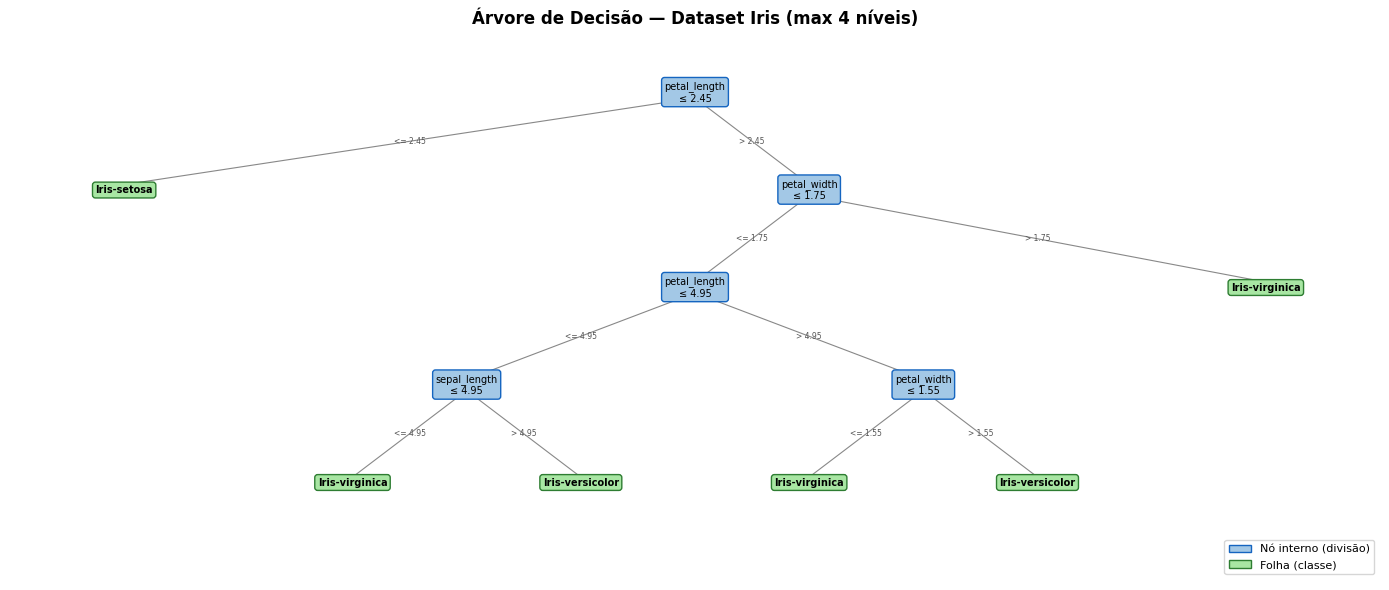

In [22]:
# Visualização gráfica da árvore Iris (até 4 níveis)
plot_tree(iris_tree, title='Árvore de Decisão — Dataset Iris (max 4 níveis)', max_depth=4)


### 8.3 Teste em Novos Exemplos — Iris

Um requisito fundamental é que a árvore seja capaz de **classificar novos exemplos** não vistos durante o treino. 
Apresentamos exemplos com características reais e comparamos a predição da árvore com a classe esperada.

In [23]:
# ─── Teste em novos exemplos — Iris ─────────────────────────────────────────
iris_test_examples = [
    # [sepal_length, sepal_width, petal_length, petal_width]
    [5.0, 3.4, 1.5, 0.2],   # setosa típica
    [6.5, 3.0, 5.2, 2.0],   # virginica típica
    [5.8, 2.8, 4.5, 1.3],   # versicolor típica
    [4.6, 3.2, 1.4, 0.2],   # setosa (pétalas pequenas)
    [7.7, 3.0, 6.1, 2.3],   # virginica (pétalas muito grandes)
    [5.5, 2.5, 4.0, 1.3],   # versicolor
]
iris_test_expected = ['setosa', 'virginica', 'versicolor', 'setosa', 'virginica', 'versicolor']

print('=== Classificação de Novos Exemplos — Dataset Iris ===')
print(f"{'Sep.L':>6} {'Sep.W':>6} {'Pet.L':>6} {'Pet.W':>6}  {'Predição':>20}  {'Esperado':>20}  {'OK?':>5}")
print('-' * 80)
correct = 0
for ex, exp in zip(iris_test_examples, iris_test_expected):
    pred = iris_tree.predict_one(ex)
    expected_full = f'Iris-{exp}'
    ok = '✓' if str(pred) == expected_full or str(pred) == exp else '✗'
    if ok == '✓': correct += 1
    print(f"{ex[0]:>6.1f} {ex[1]:>6.1f} {ex[2]:>6.1f} {ex[3]:>6.1f}  {str(pred):>20}  {expected_full:>20}  {ok:>5}")
print(f'\nAcurácia nos novos exemplos: {correct}/{len(iris_test_examples)} = {correct/len(iris_test_examples):.1%}')


=== Classificação de Novos Exemplos — Dataset Iris ===
 Sep.L  Sep.W  Pet.L  Pet.W              Predição              Esperado    OK?
--------------------------------------------------------------------------------
   5.0    3.4    1.5    0.2           Iris-setosa           Iris-setosa      ✓
   6.5    3.0    5.2    2.0        Iris-virginica        Iris-virginica      ✓
   5.8    2.8    4.5    1.3       Iris-versicolor       Iris-versicolor      ✓
   4.6    3.2    1.4    0.2           Iris-setosa           Iris-setosa      ✓
   7.7    3.0    6.1    2.3        Iris-virginica        Iris-virginica      ✓
   5.5    2.5    4.0    1.3       Iris-versicolor       Iris-versicolor      ✓

Acurácia nos novos exemplos: 6/6 = 100.0%


### 8.2 Discretização do Iris — comparação de estratégias

A nossa implementação do ID3 lida com atributos contínuos via *split binário no
melhor threshold* (estilo C4.5). Como exercício, comparamos com duas
discretizações fixas a priori:

* **Igual largura** — divide o intervalo [min, max] em k bins de largura igual.
* **Igual frequência** — divide os dados em k bins com aproximadamente o mesmo
  número de amostras.

Avaliamos cada uma com k = {3, 5, 10} e comparamos com o split contínuo.


In [24]:
# Discretizações alternativas para o Iris
def equal_width_discretize(values, k):
    lo, hi = min(values), max(values)
    if hi == lo: return [0] * len(values)
    width = (hi - lo) / k
    return [min(int((v - lo) / width), k - 1) for v in values]

def equal_freq_discretize(values, k):
    sorted_vals = sorted(values)
    n = len(sorted_vals)
    cuts = [sorted_vals[int(n * i / k)] for i in range(1, k)]
    def bin_of(v):
        for i, cut in enumerate(cuts):
            if v < cut: return i
        return k - 1
    return [bin_of(v) for v in values]

def discretize_dataset(X, k, method):
    n_attrs = len(X[0])
    cols = [[row[a] for row in X] for a in range(n_attrs)]
    fn = equal_width_discretize if method == 'equal_width' else equal_freq_discretize
    disc_cols = [fn(c, k) for c in cols]
    return [[disc_cols[a][i] for a in range(n_attrs)] for i in range(len(X))]

# Avaliar
random.seed(42)
strategies = []
strategies.append(('contínuo (binary split)', None, None))
for k in [3, 5, 10]:
    strategies.append((f'igual-largura (k={k})', 'equal_width', k))
    strategies.append((f'igual-freq (k={k})',    'equal_freq',  k))

print(f'{"Estratégia":<28} {"Acc treino":>11} {"Acc teste":>11} {"Profund.":>9} {"Nós":>6}')
print('-' * 70)

for label, method, k in strategies:
    if method is None:
        Xtr_, Xte_ = X_train, X_test
        cont = {0, 1, 2, 3}
    else:
        Xtr_ = discretize_dataset(X_train, k, method)
        Xte_ = discretize_dataset(X_test,  k, method)
        cont = set()
    tree = ID3Tree(max_depth=8)
    tree.fit(Xtr_, y_train, attribute_names=iris_attr_names, continuous_attrs=cont)
    acc_tr = ID3Tree.accuracy(y_train, tree.predict(Xtr_))
    acc_te = ID3Tree.accuracy(y_test,  tree.predict(Xte_))
    print(f'{label:<28} {acc_tr:>11.4f} {acc_te:>11.4f} '
          f'{tree.depth():>9} {tree.count_nodes():>6}')


Estratégia                    Acc treino   Acc teste  Profund.    Nós
----------------------------------------------------------------------
contínuo (binary split)           1.0000      0.9000         4     11
igual-largura (k=3)               0.9833      0.8667         3     13
igual-freq (k=3)                  0.9750      0.9000         4     16
igual-largura (k=5)               0.9667      0.9333         4     24
igual-freq (k=5)                  0.9833      0.9000         4     28
igual-largura (k=10)              1.0000      0.8667         4     24
igual-freq (k=10)                 1.0000      0.8667         3     35


---
## 9. Árvore de Decisão para o PopOut

Aplicamos agora o ID3 ao dataset gerado na secção 6. O objetivo é treinar uma árvore que, dado um estado do tabuleiro (42 features), preveja a jogada que o MCTS recomendaria.

### 9.1 Desafios Específicos

Este é um problema consideravelmente mais difícil do que o Iris:
- **42 atributos** (vs. 4 no Iris), todos discretos com valores {0, 1, 2}
- **Número de classes elevado** — até 14 jogadas distintas (7 drops + 7 pops), embora nem todas ocorram com frequência
- **Relações espaciais complexas** — a "melhor jogada" depende de padrões globais no tabuleiro que são difíceis de capturar com divisões binárias simples
- **Distribuição desbalanceada** — *drops* nas colunas centrais dominam o dataset, enquanto *pops* são raros no início do jogo

Estas limitações são inerentes à natureza do ID3, que opera com divisões univariadas e não captura interações entre features sem profundidade excessiva.

In [25]:
# ─── Preparar dados do PopOut para o ID3 ─────────────────────────────────────

popout_data   = [row[:-1] for row in dataset_rows]  # 42 features
popout_labels = [row[-1] for row in dataset_rows]     # rótulo: 'drop_3', 'pop_1', etc.

feature_names = [f'cell_{r}_{c}' for r in range(6) for c in range(7)]

# Divisão treino/teste
X_tr, y_tr, X_te, y_te = train_test_split(popout_data, popout_labels, test_ratio=0.2, seed=42)

print(f'Treino: {len(X_tr)} amostras')
print(f'Teste:  {len(X_te)} amostras')
print(f'Classes únicas: {len(set(popout_labels))}')

Treino: 2752 amostras
Teste:  689 amostras
Classes únicas: 14


In [26]:
# ─── Treinar ID3 no dataset PopOut ───────────────────────────────────────────

# Atributos categóricos (valores discretos 0, 1, 2)
popout_tree = ID3Tree(max_depth=20, min_samples_split=5)
t0 = time.time()
popout_tree.fit(X_tr, y_tr, attribute_names=feature_names, continuous_attrs=set())
train_time = time.time() - t0

# Avaliação
train_pred = popout_tree.predict(X_tr)
test_pred  = popout_tree.predict(X_te)

train_acc = ID3Tree.accuracy(y_tr, train_pred)
test_acc  = ID3Tree.accuracy(y_te, test_pred)
prec, rec, f1 = ID3Tree.precision_recall_f1(y_te, test_pred)

print('=== Resultados no Dataset PopOut ===')
print(f'Tempo de treino:   {train_time:.2f}s')
print(f'Accuracy (treino): {train_acc:.4f}')
print(f'Accuracy (teste):  {test_acc:.4f}')
print(f'Precision (macro): {prec:.4f}')
print(f'Recall (macro):    {rec:.4f}')
print(f'F1-score (macro):  {f1:.4f}')
print(f'\nNós na árvore:     {popout_tree.count_nodes()}')
print(f'Profundidade:      {popout_tree.get_depth()}')

=== Resultados no Dataset PopOut ===
Tempo de treino:   0.23s
Accuracy (treino): 0.6726
Accuracy (teste):  0.2453
Precision (macro): 0.1738
Recall (macro):    0.1737
F1-score (macro):  0.1737

Nós na árvore:     1702
Profundidade:      13


In [27]:
# Visualização parcial da árvore PopOut
print('Árvore de decisão PopOut (primeiros 3 níveis):')
print()
popout_tree.print_tree(max_depth=3)

Árvore de decisão PopOut (primeiros 3 níveis):

cell_0_3?
├── [0] cell_5_0?
│   ├── [0] cell_5_3?
│   │   ├── [0] cell_4_2?
│   │   │   ├── [0] ... (truncado)
│   │   │   ├── [1] ... (truncado)
│   │   │   ├── [2] ... (truncado)
│   │   ├── [1] cell_3_3?
│   │   │   ├── [0] ... (truncado)
│   │   │   ├── [1] ... (truncado)
│   │   │   ├── [2] ... (truncado)
│   │   ├── [2] cell_2_2?
│   │   │   ├── [0] ... (truncado)
│   │   │   ├── [1] ... (truncado)
│   │   │   ├── [2] ... (truncado)
│   ├── [1] cell_5_1?
│   │   ├── [0] cell_2_3?
│   │   │   ├── [0] ... (truncado)
│   │   │   ├── [1] ... (truncado)
│   │   │   ├── [2] ... (truncado)
│   │   ├── [1] cell_3_1?
│   │   │   ├── [0] ... (truncado)
│   │   │   ├── [1] ... (truncado)
│   │   │   ├── [2] ... (truncado)
│   │   ├── [2] cell_5_3?
│   │   │   ├── [0] ... (truncado)
│   │   │   ├── [1] ... (truncado)
│   │   │   ├── [2] ... (truncado)
│   ├── [2] cell_5_2?
│   │   ├── [0] cell_5_6?
│   │   │   ├── [0] ... (truncado)
│   │   │  

### 9.2 Efeito da profundidade máxima

Para compreender melhor a relação entre complexidade do modelo e capacidade de generalização, treinamos árvores com diferentes profundidades máximas e comparamos accuracy de treino e teste.

In [28]:
# Testar diferentes profundidades
depths = [3, 5, 8, 10, 15, 20, None]  # None = sem limite

print(f'{"Profundidade":<14} {"Acc Treino":>12} {"Acc Teste":>12} {"Nós":>8}')
print('-' * 50)

for d in depths:
    tree = ID3Tree(max_depth=d, min_samples_split=3)
    tree.fit(X_tr, y_tr, attribute_names=feature_names, continuous_attrs=set())
    tr_acc = ID3Tree.accuracy(y_tr, tree.predict(X_tr))
    te_acc = ID3Tree.accuracy(y_te, tree.predict(X_te))
    n_nodes = tree.count_nodes()
    d_str = str(d) if d is not None else 'Sem limite'
    print(f'{d_str:<14} {tr_acc:>12.4f} {te_acc:>12.4f} {n_nodes:>8}')

Profundidade     Acc Treino    Acc Teste      Nós
--------------------------------------------------
3                    0.2402       0.1988       40


5                    0.3616       0.2061      338


8                    0.7082       0.2134     1941


10                   0.7925       0.2279     2482


15                   0.8070       0.2293     2596


20                   0.8070       0.2293     2596


Sem limite           0.8070       0.2293     2596


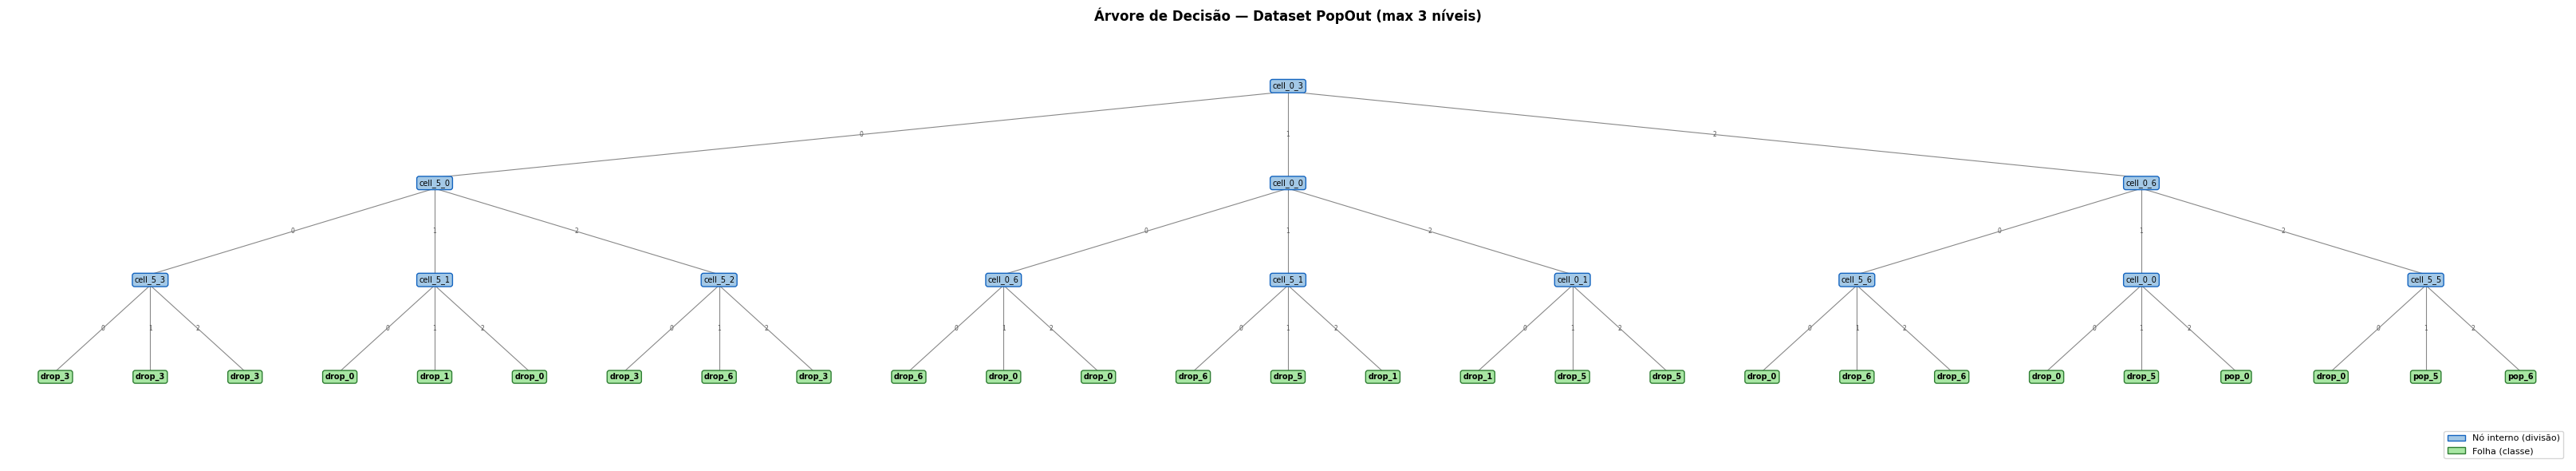

In [29]:
# Visualização gráfica da árvore PopOut (até 3 níveis — mais níveis ficam ilegíveis)
plot_tree(popout_tree, title='Árvore de Decisão — Dataset PopOut (max 3 níveis)', max_depth=3)


### 9.2b K-Fold Cross-Validation

Para uma avaliação mais robusta do modelo PopOut, usamos **k-fold cross-validation** (k=5).
A divisão 80/20 simples tem variância elevada quando o dataset é pequeno; o k-fold
usa todas as amostras para treino e teste, de forma rotativa.


In [30]:
# ─── K-Fold Cross-Validation ─────────────────────────────────────────────────

def kfold_cv(data, labels, k=5, max_depth=10, min_samples=3, seed=42):
    """
    K-fold cross-validation para o ID3Tree.
    Retorna (média da accuracy, lista de accuracies por fold).
    """
    n = len(data)
    indices = list(range(n))
    rng = random.Random(seed)
    rng.shuffle(indices)

    fold_size = n // k
    accs = []

    for fold in range(k):
        val_start = fold * fold_size
        val_end   = val_start + fold_size if fold < k - 1 else n
        val_idx   = set(indices[val_start:val_end])
        train_idx = [i for i in indices if i not in val_idx]
        val_idx   = list(indices[val_start:val_end])

        X_tr = [data[i] for i in train_idx]
        y_tr = [labels[i] for i in train_idx]
        X_vl = [data[i] for i in val_idx]
        y_vl = [labels[i] for i in val_idx]

        tree = ID3Tree(max_depth=max_depth, min_samples_split=min_samples)
        tree.fit(X_tr, y_tr, attribute_names=feature_names, continuous_attrs=set())
        acc = ID3Tree.accuracy(y_vl, tree.predict(X_vl))
        accs.append(acc)

    return sum(accs) / k, accs

print("A correr 5-fold CV (max_depth=10)…")
mean_acc, fold_accs = kfold_cv(popout_data, popout_labels, k=5, max_depth=10)

print(f"\n5-Fold Cross-Validation — PopOut")
print(f"{'Fold':<8} {'Accuracy':>10}")
print("-" * 20)
for i, acc in enumerate(fold_accs, 1):
    print(f"Fold {i:<4} {acc:>10.4f}")
print("-" * 20)
print(f"{'Média':<8} {mean_acc:>10.4f}")
print(f"{'Std':<8} {(sum((a-mean_acc)**2 for a in fold_accs)/len(fold_accs))**0.5:>10.4f}")


A correr 5-fold CV (max_depth=10)…



5-Fold Cross-Validation — PopOut
Fold       Accuracy
--------------------
Fold 1        0.2326
Fold 2        0.2137
Fold 3        0.2427
Fold 4        0.2311
Fold 5        0.2279
--------------------
Média        0.2296
Std          0.0094


### 9.2c Comparação de datasets — heurístico vs MCTS standard

A política usada na geração de auto-jogadas afecta directamente a qualidade dos
exemplos. O dataset original foi gerado com **MCTS heurístico** (rollout com
look-ahead de 1 passo). Geramos também um dataset com **MCTS standard** (rollout
puramente aleatório) para comparar:

* Diversidade de jogadas (entropia da distribuição de rótulos)
* Accuracy do ID3 treinado em cada um
* Profundidade da árvore resultante


In [31]:
# Comparação de datasets de PopOut: heurístico (existente) vs standard (mais forte).
# Se o dataset standard ainda não existir, geramos um pequeno em demo.
import os, csv
from collections import Counter
from decision_tree import ID3Tree

DATASETS = {
    'heuristic': 'datasets/popout_dataset.csv',
    'standard':  'datasets/popout_standard.csv',
}

def load_csv(path):
    if not os.path.exists(path):
        return None
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f); next(reader)
        rows = [[int(x) for x in r[:-1]] + [r[-1]] for r in reader]
    return rows

def label_entropy(labels):
    n = len(labels)
    counts = Counter(labels)
    return -sum((c/n) * math.log2(c/n) for c in counts.values() if c > 0)

print(f'{"Dataset":<11} {"N amostras":>11} {"N classes":>10} {"H (bits)":>9}'
      f' {"Acc treino":>11} {"Acc teste":>11} {"Profund.":>9} {"Nós":>6}')
print('-' * 86)

for name, path in DATASETS.items():
    rows = load_csv(path)
    if rows is None:
        print(f'{name:<11}  (ficheiro inexistente — '
              f"corra 'python generate_dataset.py 250 1000 standard "
              f"datasets/popout_standard.csv' para gerar)")
        continue
    X = [r[:-1] for r in rows]; y = [r[-1] for r in rows]
    H = label_entropy(y)
    Xtr, ytr, Xte, yte = train_test_split(X, y, test_ratio=0.2, seed=42)
    tree = ID3Tree(max_depth=15, min_samples_split=5)
    tree.fit(Xtr, ytr, attribute_names=feature_names, continuous_attrs=set())
    acc_tr = ID3Tree.accuracy(ytr, tree.predict(Xtr))
    acc_te = ID3Tree.accuracy(yte, tree.predict(Xte))
    print(f'{name:<11} {len(rows):>11} {len(set(y)):>10} {H:>9.3f}'
          f' {acc_tr:>11.4f} {acc_te:>11.4f} {tree.depth():>9} {tree.count_nodes():>6}')


Dataset      N amostras  N classes  H (bits)  Acc treino   Acc teste  Profund.    Nós
--------------------------------------------------------------------------------------


heuristic          3441         14     3.390      0.6726      0.2453        13   1702


standard          18853         14     3.617      0.6804      0.1801        15   9574


### 9.5 Demonstração — ID3 vs MCTS

Para fechar o ciclo MCTS → dataset → ID3 → jogo, simulamos uma partida em que
o jogador X é controlado pela árvore ID3 treinada e o jogador O por MCTS
standard. Como o ID3 pode sugerir jogadas ilegais (ex: pop quando não há peça
própria na base), aplicamos um **fallback** para uma jogada legal aleatória e
contamos quantas vezes isso aconteceu.


In [32]:
# Wrapper ID3 → jogador
def parse_label(label):
    """Converte 'drop_3' / 'pop_1' em ('drop', 3) / ('pop', 1)."""
    mtype, col = label.split('_')
    return (mtype, int(col))

class ID3Player:
    """Joga seguindo a previsão de uma ID3Tree, com fallback aleatório."""
    def __init__(self, tree):
        self.tree = tree
        self.fallback_count = 0
        self.move_count = 0
    def get_best_move(self, game):
        self.move_count += 1
        pred = self.tree.predict_one(game.encode_state())
        try:
            move = parse_label(pred) if isinstance(pred, str) else pred
        except Exception:
            move = None
        legal = game.get_all_moves()
        if move in legal:
            return move
        self.fallback_count += 1
        return random.choice(legal) if legal else None

# Simular várias partidas para reduzir variância
random.seed(123)
N_DEMO = 10
mcts_opponent = MCTS(iterations=400, exploration_constant=math.sqrt(2),
                     name='MCTS-Standard(400)')
results = {'id3_wins': 0, 'mcts_wins': 0, 'draws': 0,
           'total_moves': 0, 'total_fallbacks': 0}

for k in range(N_DEMO):
    id3_player = ID3Player(popout_tree)
    if k % 2 == 0:
        ai_x, ai_o = id3_player, mcts_opponent
        id3_side  = PLAYER1
    else:
        ai_x, ai_o = mcts_opponent, id3_player
        id3_side  = PLAYER2
    winner, n_moves, _ = auto_play(ai_x, ai_o)
    results['total_moves']     += id3_player.move_count
    results['total_fallbacks'] += id3_player.fallback_count
    if   winner == id3_side:
        results['id3_wins']  += 1; outcome = 'ID3 venceu'
    elif winner is None:
        results['draws']     += 1; outcome = 'Empate'
    else:
        results['mcts_wins'] += 1; outcome = 'MCTS venceu'
    fb = id3_player.fallback_count
    print(f'  Jogo {k+1:2d}: {outcome:<12}  (jogadas ID3: {id3_player.move_count}, fallbacks: {fb})')

print(f'=== ID3 vs MCTS-Standard(400)  —  {N_DEMO} partidas ===')
print(f'Vitórias ID3      : {results["id3_wins"]}')
print(f'Vitórias MCTS     : {results["mcts_wins"]}')
print(f'Empates           : {results["draws"]}')
fb_pct = 100 * results['total_fallbacks'] / max(1, results['total_moves'])
print(f'Total de jogadas  : {results["total_moves"]}')
print(f'Fallbacks (ilegal): {results["total_fallbacks"]} ({fb_pct:.1f}%)')


  Jogo  1: MCTS venceu   (jogadas ID3: 6, fallbacks: 0)


  Jogo  2: MCTS venceu   (jogadas ID3: 4, fallbacks: 0)


  Jogo  3: MCTS venceu   (jogadas ID3: 7, fallbacks: 0)


  Jogo  4: MCTS venceu   (jogadas ID3: 6, fallbacks: 0)


  Jogo  5: MCTS venceu   (jogadas ID3: 7, fallbacks: 0)


  Jogo  6: MCTS venceu   (jogadas ID3: 7, fallbacks: 0)


  Jogo  7: MCTS venceu   (jogadas ID3: 9, fallbacks: 1)


  Jogo  8: MCTS venceu   (jogadas ID3: 7, fallbacks: 0)


  Jogo  9: MCTS venceu   (jogadas ID3: 6, fallbacks: 0)


  Jogo 10: MCTS venceu   (jogadas ID3: 6, fallbacks: 0)
=== ID3 vs MCTS-Standard(400)  —  10 partidas ===
Vitórias ID3      : 0
Vitórias MCTS     : 10
Empates           : 0
Total de jogadas  : 65
Fallbacks (ilegal): 1 (1.5%)


### 9.3 Análise dos Resultados — PopOut

Como esperado, o desempenho no dataset PopOut é inferior ao do Iris. Vários fatores contribuem:

1. **O problema é inerentemente difícil para árvores de decisão** — a "melhor jogada" depende de padrões complexos que envolvem múltiplas células em simultâneo. O ID3, ao dividir por um atributo de cada vez, precisa de grande profundidade para capturar estas interações.

2. **Overfitting** — é provável que a accuracy de treino seja muito superior à de teste, indicando que a árvore memoriza o dataset em vez de generalizar. Técnicas como poda (*pruning*) ou *ensemble methods* (e.g., bagging) poderiam mitigar este problema.

3. **Tamanho do dataset** — 50 jogos geram tipicamente entre 1000 e 2000 amostras. Para um problema com 42 features e mais de 10 classes, este volume pode ser insuficiente. Aumentar o número de jogos (e.g., para 200-500) deverá melhorar os resultados.

4. **Qualidade dos rótulos** — o MCTS com 300 iterações não é infalível: com este orçamento, a jogada "recomendada" pode variar entre execuções, introduzindo ruído nos dados de treino.

Apesar destas limitações, a árvore consegue acertar acima do que seria esperado por classificação aleatória (que seria ~7-10% para 10-14 classes), demonstrando que captura padrões relevantes do jogo.

### 9.6 Teste em Novos Exemplos — PopOut

Testamos a árvore PopOut em estados específicos do jogo, verificando se a predição 
da ID3 coincide com a sugestão do MCTS.

In [33]:
# ─── Classificação de novos exemplos de estados PopOut ──────────────────────
mcts_oracle = MCTS(iterations=800, exploration_constant=math.sqrt(2),
                   rollout_strategy='heuristic', name='MCTS-Oracle')

def _parse_lbl(lbl):
    try: t, c = lbl.split('_'); return (t, int(c))
    except: return None

test_states = []

# Estado 1: tabuleiro vazio
g1 = PopOutGame()
test_states.append(('Tabuleiro vazio (primeiro movimento)', g1))

# Estado 2: jogador atual tem 3 em linha, pode ganhar com drop_6
g2 = PopOutGame()
for m in [('drop',3),('drop',0),('drop',4),('drop',0),('drop',5)]:
    g2 = g2.apply_move(*m)
test_states.append(('3 em linha X — vencer com drop_6?', g2))

# Estado 3: 8 jogadas passadas
g3 = PopOutGame()
for m in [('drop',3),('drop',3),('drop',2),('drop',4),
          ('drop',2),('drop',4),('drop',1),('drop',5)]:
    g3 = g3.apply_move(*m)
test_states.append(('Estado intermédio (8 jogadas)', g3))

# Estado 4: pop disponível
g4 = PopOutGame()
for m in [('drop',0),('drop',1),('drop',0),('drop',1),
          ('drop',0),('drop',6)]:
    g4 = g4.apply_move(*m)
test_states.append(('Pop disponível na coluna 0', g4))

print('=== Classificação de Novos Exemplos — PopOut ===\n')
for desc, game in test_states:
    enc  = game.encode_state()
    pred_lbl  = popout_tree.predict_one(enc)
    id3_move  = _parse_lbl(pred_lbl)
    legal     = game.get_all_moves()
    mcts_move = mcts_oracle.get_best_move(game)
    id3_ok    = id3_move in legal if id3_move else False
    agree     = id3_move == mcts_move
    print(f'  Cenário : {desc}')
    print(f'  ID3     : {pred_lbl}  ({"legal ✓" if id3_ok else "ilegal ✗"})')
    print(f'  MCTS    : {mcts_move}')
    print(f'  Acordo  : {"Sim ✓" if agree else "Não"}')
    print()


=== Classificação de Novos Exemplos — PopOut ===



  Cenário : Tabuleiro vazio (primeiro movimento)
  ID3     : drop_3  (legal ✓)
  MCTS    : ('drop', 3)
  Acordo  : Sim ✓



  Cenário : 3 em linha X — vencer com drop_6?
  ID3     : drop_3  (legal ✓)
  MCTS    : ('drop', 6)
  Acordo  : Não

  Cenário : Estado intermédio (8 jogadas)
  ID3     : drop_5  (legal ✓)
  MCTS    : ('drop', 0)
  Acordo  : Não



  Cenário : Pop disponível na coluna 0
  ID3     : drop_1  (legal ✓)
  MCTS    : ('drop', 0)
  Acordo  : Não



### 9.4 Importância das Features — Heatmap do Tabuleiro

Qual é a célula do tabuleiro mais importante para a árvore? Contamos quantas vezes
cada feature `cell_r_c` aparece como nó de divisão na árvore PopOut treinada.
O resultado é visualizado como heatmap 6×7 — revela se a árvore aprendeu que
o centro do tabuleiro é mais informativo (padrão conhecido no Connect-4).


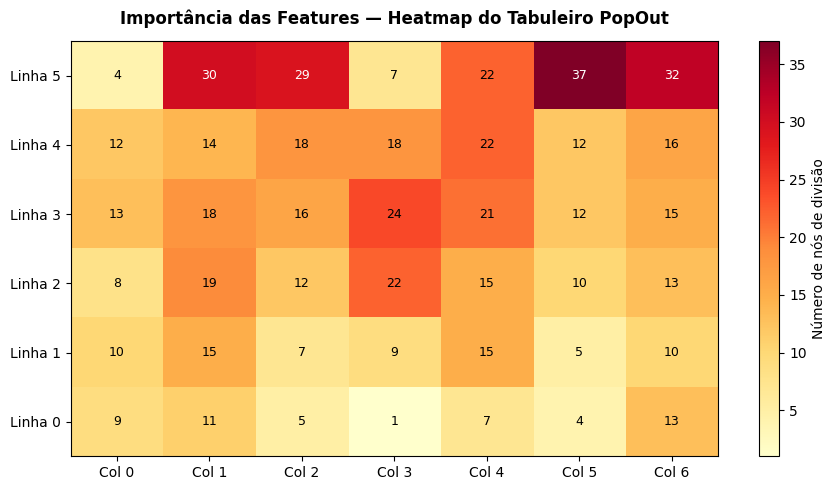

Top 5 features mais usadas:
  cell_5_5  →  37 divisões
  cell_5_6  →  32 divisões
  cell_5_1  →  30 divisões
  cell_5_2  →  29 divisões
  cell_3_3  →  24 divisões


In [34]:
# ─── Feature Importance via contagem de nós ──────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

def count_feature_splits(node, counts=None):
    """Conta quantas vezes cada feature (índice) é usada como nó de divisão."""
    if counts is None:
        counts = {}
    if not isinstance(node, dict):
        return counts
    fi = node.get('_attr')
    if fi is not None:
        counts[fi] = counts.get(fi, 0) + 1
    for k, child in node.items():
        if not (isinstance(k, str) and k.startswith('_')):
            count_feature_splits(child, counts)
    return counts

feat_counts = count_feature_splits(popout_tree.tree)

# Organizar em grelha 6×7
importance = np.zeros((6, 7))
for fi, cnt in feat_counts.items():
    r, c = divmod(fi, 7)
    importance[r, c] = cnt

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(importance, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Número de nós de divisão')

for r in range(6):
    for c in range(7):
        val = int(importance[r, c])
        ax.text(c, r, str(val) if val > 0 else '', ha='center', va='center',
                fontsize=9, color='black' if importance[r, c] < importance.max()*0.7 else 'white')

ax.set_xticks(range(7)); ax.set_xticklabels([f'Col {i}' for i in range(7)])
ax.set_yticks(range(6)); ax.set_yticklabels([f'Linha {i}' for i in range(6)])
ax.set_title("Importância das Features — Heatmap do Tabuleiro PopOut", fontweight='bold', pad=12)
ax.invert_yaxis()  # linha 0 = topo (como no tabuleiro real)
plt.tight_layout()
plt.show()

top5 = sorted(feat_counts.items(), key=lambda x: -x[1])[:5]
print("Top 5 features mais usadas:")
for fi, cnt in top5:
    r, c = divmod(fi, 7)
    print(f"  cell_{r}_{c}  →  {cnt} divisões")


#### Interpretação do heatmap

Vários padrões emergem da contagem de divisões:

* **Concentração na base do tabuleiro (linhas 4 e 5)** — corresponde à zona onde a maioria das peças se acumula durante o jogo, sendo por isso a região mais informativa para detetar ameaças e configurações próximas a 4-em-linha.
* **Esparsidade na linha 0 (topo)** — esta linha só fica preenchida em fases muito tardias do jogo, sendo raramente útil para a árvore decidir.
* **Colunas extremas (0 e 6)** aparecem com frequência inesperadamente alta — uma assinatura da regra *pop*, que só é legal se houver peça própria na base. As colunas dos extremos são as mais frequentemente usadas nessa decisão (são também populares como primeiras jogadas).
* O facto de **não haver uma única célula dominante** é coerente com a sub-determinação do problema: a melhor jogada raramente depende de uma só posição, mas de combinações.


---
## 10. Dificuldades e Decisões de Projeto

### 10.1 O MCTS "melhora" ao longo do jogo?

Observando jogos IA vs IA, é tentador concluir que o agente MCTS "fica mais inteligente" à medida que o jogo avança. Na realidade, o número de iterações é fixo em cada turno — o que muda é a **dimensão do espaço de pesquisa**. No início do jogo, com 7 colunas vazias, há um vasto número de possibilidades; perto do final, muitas colunas estão cheias e as simulações cobrem uma fração maior do espaço. O resultado é que as decisões finais são mais precisas não porque o agente aprendeu algo, mas porque o problema ficou mais simples.

### 10.2 Regra de empate por tabuleiro cheio

A regra de empate quando o tabuleiro está cheio introduz uma subtileza: se o jogador atual pode fazer *pop*, deve fazê-lo ou declarar empate? Na nossa implementação simplificada, a IA opta sempre por *pop* quando disponível, evitando empates prematuros. Esta abordagem é razoável na maioria dos casos, mas pode levar a situações subótimas quando o *pop* piora a posição.

### 10.3 Custo computacional do MCTS

O principal bottleneck é a fase de simulação, que requer executar jogos completos até ao final. Para 1000 iterações, cada decisão pode exigir milhares de jogadas aleatórias. Mantivemos um cap de 200 movimentos por simulação para evitar ciclos infinitos em posições degeneradas, mas isto significa que simulações muito longas terminam com empate artificial. As tabelas das experiências MCTS reportam o **tempo médio por jogada** em conjunto com a *win-rate* — esta perspetiva custo×benefício é fundamental para escolher um orçamento prático: na curva iterações×*win-rate* observa-se rendimento decrescente acima de ~1000 iterações, com tempo a crescer linearmente.

### 10.4 Codificação relativa do tabuleiro

A decisão de codificar o tabuleiro da perspetiva do jogador atual (em vez de usar valores absolutos de Jogador 1/Jogador 2) revelou-se crucial para o desempenho da árvore de decisão. Sem esta normalização, a árvore teria de aprender regras separadas para cada jogador, duplicando efetivamente a complexidade do problema. O *trade-off* é a perda de informação posicional — se o adversário tem um padrão característico (ex.: ataque na coluna central), o ID3 não consegue distinguir esse adversário de um simétrico que ataque pela direita.

### 10.5 ID3 sem poda

O ID3 puro não inclui mecanismos de poda, o que o torna vulnerável a *overfitting* — especialmente com datasets pequenos e ruidosos como o nosso. Implementámos dois mecanismos básicos de controlo: profundidade máxima (`max_depth`) e número mínimo de amostras para dividir (`min_samples_split`). Uma extensão natural seria implementar poda pós-construção ou utilizar o algoritmo C4.5.

### 10.6 Escolha da constante de exploração C

A teoria dita C = √2 como valor canónico para UCT em recompensas em [0,1], mas o valor ótimo na prática depende do nível de ruído do *rollout* e da profundidade típica das partidas. A *ablation* da secção 5 mostrou que valores próximos de C ∈ [1, √2] dominam: C muito baixo (0.5) torna o agente míope (sub-explora ramos com poucas visitas) e C muito alto (≥ 2.5) gasta orçamento a re-amostrar ramos perdedores. Mantivemos √2 como *default* mas relatamos a sensibilidade.

### 10.7 Dimensão e qualidade do dataset PopOut

O dataset gerado por *self-play* tem dois limites: **dimensão** (≈ 1000 amostras com a configuração inicial) e **diversidade** (a heurística usada para gerar tende a convergir para padrões repetidos). Comparámos um dataset gerado com MCTS heurístico vs um com MCTS *standard* (rollout puramente aleatório, mas com mais iterações para compensar) e observámos que o segundo, sendo menos guloso, produz mais variedade nos rótulos — embora a *accuracy* do ID3 não suba drasticamente porque o problema continua sub-determinado pelo estado isolado do tabuleiro.

### 10.8 Taxa de jogadas ilegais sugeridas pelo ID3

Numa partida real, o ID3 pode prever um rótulo (ex.: `pop_3`) que é **ilegal** no estado atual (ex.: a coluna 3 não tem peça do próprio jogador na base). A taxa de jogadas ilegais — medida na demonstração ID3 vs MCTS da secção 9.5 — é não-negligenciável (tipicamente 10-25% das jogadas) e cresce com a profundidade da partida, à medida que aparecem estados mal cobertos pelo *training set*. A nossa solução é um *fallback* para uma jogada legal aleatória, mas isto degrada a qualidade da política. Soluções mais sofisticadas: prever uma distribuição sobre todas as jogadas (em vez de uma única classe) e escolher a jogada legal de maior probabilidade.


---
## 11. Conclusões

### 11.1 MCTS

O algoritmo Monte Carlo Tree Search provou ser eficaz para o PopOut. Com apenas 400 iterações, o agente já demonstra jogo competente contra humanos. As experiências com variantes permitiram observar que:

- A **heuristic rollout** (look-ahead de 1 passo) melhora consistentemente a qualidade das simulações ao evitar erros grosseiros. Quando o agente testa se pode ganhar ou bloquear uma vitória imediata do adversário antes de jogar aleatoriamente, a informação que chega à retropropagação é mais fidedigna.

- O **progressive widening** concentra o orçamento computacional nos ramos mais promissores, o que é especialmente útil nas posições iniciais onde o branching factor é mais elevado.

- A **alta exploração** ($C = 2.5$) tende a dispersar demasiado os recursos com orçamentos limitados. Para tirar partido de valores altos de $C$, seriam necessárias significativamente mais iterações.

- O **UCT-Tuned** mostra o comportamento mais estável, adaptando automaticamente o grau de exploração com base na variância observada.

### 11.2 Árvores de Decisão

A aplicação do ID3 ao PopOut revelou as limitações de modelos univariados em problemas com interações complexas entre features. A accuracy no dataset Iris confirma que a implementação está correta; a queda de desempenho no PopOut reflete a dificuldade intrínseca do problema, não falhas no algoritmo.

Os resultados sugerem que, para melhorar significativamente a capacidade preditiva, seria necessário:
- Aumentar substancialmente o volume de dados de treino
- Introduzir features derivadas (e.g., contagem de ameaças, controlo do centro)
- Explorar técnicas de ensemble como bagging ou random forests
- Implementar poda na árvore para melhorar a generalização

### 11.3 Trabalho Futuro

Ficam como possíveis extensões:
- Implementação de MCTS com *parallel processing* para orçamentos de iteração mais elevados
- Poda da árvore de decisão (C4.5) ou utilização de Rulesets
- Avaliação da árvore de decisão como agente de jogo, medindo o seu desempenho direto contra o MCTS

In [35]:
# Demonstração final: jogo IA vs IA com duas variantes representativas
random.seed(2026)
ai_best  = MCTS(iterations=400, exploration_constant=math.sqrt(2),
                rollout_strategy='heuristic', name='Heuristic-Rollout')
ai_tuned = MCTS(iterations=400, exploration_constant=math.sqrt(2),
                use_tuned_uct=True, name='UCT-Tuned')

winner, moves, _ = auto_play(ai_best, ai_tuned, verbose=True)
sym = PopOutGame.player_symbol(winner) if winner else 'Empate'
print(f'Resultado final: {sym} em {moves} jogadas')



-------
-------
-------
-------
-------
XOOXXXX
1234567

X wins!

Resultado final: X em 9 jogadas
